In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
parquet_file_path = '../data/raw_inca_cancer_populacional.parquet' 
data = pd.read_parquet(parquet_file_path, engine='pyarrow')

In [3]:
display(data.head())

,Código do Paciente,Nome do RCBP,Sexo,Data de Nascimento,Idade,Raca/Cor,Nacionalidade,Naturalidade Estado,Naturalidade,Grau de Instrução,...,Extensão,Lateralidade,Estadiamento,TNM,Status Vital,Tipo do Obito,Data do Óbito,Data de Último Contato,Data de Diagnostico,Metástase à distância
0,130330,RCBP PORTO ALEGRE,FEMININO,20/12/1969,23,BRANCO,Não informado,Não informado,Não Informado,SEM INFORMAÇÃO,...,LOCALIZADO,None,None,None,None,None,None,None,16/04/1993,None
1,136219,RCBP PORTO ALEGRE,FEMININO,10/11/1923,69,BRANCO,BRASIL,Não informado,None,FUNDAMENTAL I (1ª A 4ª SÉRIE),...,LOCALIZADO,None,None,None,None,NÃO CÂNCER,13/08/2011,None,02/07/1993,None
2,135314,RCBP PORTO ALEGRE,MASCULINO,23/01/1917,76,BRANCO,BRASIL,Não informado,None,SEM INFORMAÇÃO,...,LOCALIZADO,None,None,None,None,CÂNCER,25/07/2009,None,17/05/1993,None
3,136992,RCBP PORTO ALEGRE,FEMININO,25/07/1934,59,BRANCO,Não informado,Não informado,Não Informado,SEM INFORMAÇÃO,...,LOCALIZADO,None,None,None,None,CÂNCER,06/12/2008,None,09/11/1993,None
4,133667,RCBP PORTO ALEGRE,MASCULINO,04/03/1943,49,BRANCO,BRASIL,Não informado,Não Informado,SEM INFORMAÇÃO,...,NÃO SE APLICA,None,None,None,None,CÂNCER,25/03/2013,None,05/02/1993,None


/tmp/ipykernel_5495/2265352351.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='null_percent', y='column', data=null_data, palette='viridis')


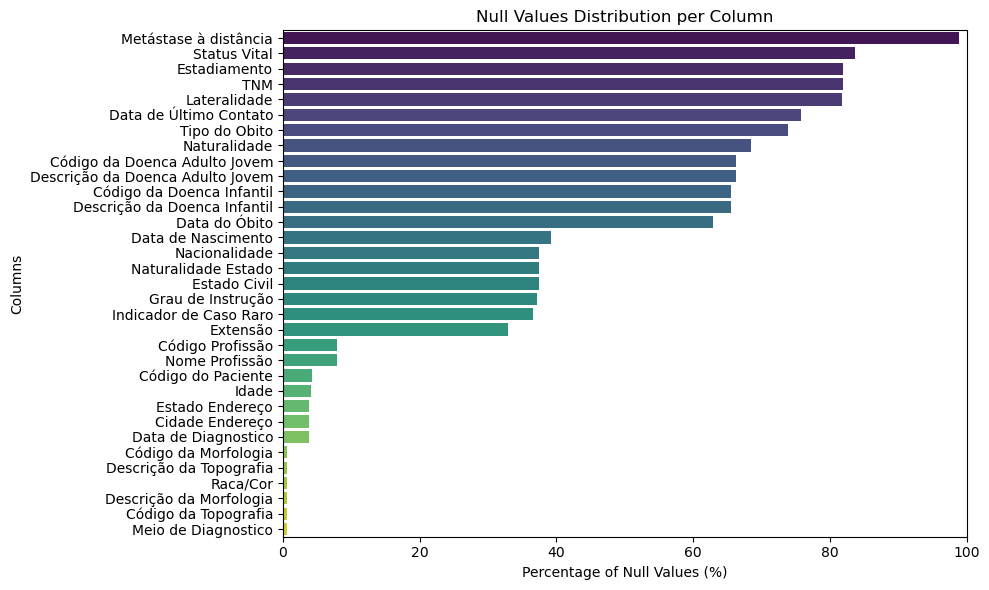

,Código do Paciente,Nome do RCBP,Sexo,Data de Nascimento,Idade,Raca/Cor,Nacionalidade,Naturalidade Estado,Naturalidade,Grau de Instrução,...,Extensão,Lateralidade,Estadiamento,TNM,Status Vital,Tipo do Obito,Data do Óbito,Data de Último Contato,Data de Diagnostico,Metástase à distância
count,2269333,2368916,2368916,1438468,2272005,2355519,1480346,1482793,748284,1490233,...,1589392,432377,430018,430086,387271,618559,878611,572408,2279920,26794
unique,1489845,33,3,40288,133,6,126,28,4645,7,...,5,5,229,1070,3,3,12151,11346,11594,862
top,773789,RCBP SÃO PAULO,FEMININO,01/01/1940,65,SEM INFORMAÇÃO,BRASIL,Não informado,Não Informado,SEM INFORMAÇÃO,...,SEM INFORMAÇÃO,NÃO SE APLICA,99,999,MORTO,CÂNCER,29/10/2012,29/10/2012,01/07/2008,C76
freq,34,766127,1295604,267,55519,990657,1168851,869909,477776,926676,...,815401,237278,224166,340512,179906,535132,848,76889,1270,4050


In [ ]:
def plot_null_distribution(df):
    null_counts = df.isnull().sum()
    null_percent = (null_counts / len(df)) * 100
    null_data = pd.DataFrame({'column': null_counts.index, 'null_count': null_counts.values, 'null_percent': null_percent.values})
    null_data = null_data[null_data['null_count'] > 0].sort_values(by='null_percent', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='null_percent', y='column', data=null_data, palette='viridis')
    plt.xlabel('Percentage of Null Values (%)')
    plt.ylabel('Columns')
    plt.title('Null Values Distribution per Column')
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

plot_null_distribution(data)
# summary statistics
summary_stats = data.describe(include='all')
display(summary_stats)